In [2]:
import sys, os
# sys.path.append('process')

from tqdm.notebook import tqdm

import warnings
import numpy as np
import pandas as pd

from Bio import BiopythonWarning
from Bio.PDB import PDBParser, PDBIO, Select
warnings.simplefilter("ignore", BiopythonWarning)

from placer.process import structure
from placer.process import cluster
from placer.process import symmetry
from placer.process import preorganization as po

In [3]:
class ProteinOnly(Select):
    def accept_residue(self, residue):
        return residue.id[0] == " "

In [4]:
from placer.process.structure import get_coord, get_ligand_heavy_coords

def build_catalytic_key_res(model, cat_res, chain_id="A"):
    """
    Description:
        Build a key-residue list (find_key_residues format) by looking up
        catalytic resids on the model.

    Args:
        model: Bio.PDB Model used to read resnames.
        cat_res: Dict mapping label -> residue index (e.g. {"His": 294}).
        chain_id: Chain identifier where the residues live.

    Returns:
        List of dicts with chain/resid/resname. Residues missing from the
        model are skipped.
    """
    out = []
    for resid in cat_res.values():
        try:
            res = model[chain_id][(" ", resid, " ")]
        except KeyError:
            continue
        out.append({"chain": chain_id, "resid": resid,
                    "resname": res.get_resname().strip()})
    return out

def resolve_symmetric_atom(ligand, atom_name, partner_xyz, sym_pairs=None):
    """
    Description:
        Pick the symmetry-equivalent atom of a ligand closer to partner_xyz.

    Args:
        ligand: Ligand dict from get_ligand_heavy_coords.
        atom_name: Requested ligand atom name.
        partner_xyz: Reference 3D point.
        sym_pairs: List of (atom_name, atom_name) swap tuples; None disables.

    Returns:
        Effective atom name closer to partner_xyz, or input atom_name unchanged.
    """
    if sym_pairs is None:
        return atom_name
    candidates = {atom_name} | {b for a, b in sym_pairs if a == atom_name}
    candidates &= set(ligand["atoms"])
    if len(candidates) <= 1:
        return atom_name
    best_name, best_d = atom_name, np.inf
    for n in candidates:
        xyz = ligand["coords"][ligand["atoms"].index(n)]
        d = np.linalg.norm(xyz - partner_xyz)
        if d < best_d:
            best_d, best_name = d, n
    return best_name

def compute_pair_distances(models, pairs, sym_pairs=None):
    """
    Description:
        Compute atom-atom distances for a list of pair specs across all models.
        Each pair is a dict {label: spec} with exactly two entries.

    Args:
        models: List of Bio.PDB Models.
        pairs: List of dicts, each with two {label: spec} entries.
        sym_pairs: Optional symmetry swap pairs; the partner atom acts as anchor.

    Returns:
        Dict mapping "labelA-labelB" to ndarray of length n_models in Angstrom.
    """
    out = {}
    for pair in pairs:
        (label_a, spec_a), (label_b, spec_b) = list(pair.items())
        joint_label = f"{label_a}-{label_b}"
        dists = []
        for m in models:
            xa = _get_atom_xyz(m, spec_a, partner_xyz=None, sym_pairs=sym_pairs)
            xb = _get_atom_xyz(m, spec_b, partner_xyz=xa, sym_pairs=sym_pairs)
            dists.append(float(np.linalg.norm(xa - xb)))
        out[joint_label] = np.array(dists)
    return out


def _get_atom_xyz(model, spec, partner_xyz=None, sym_pairs=None):
    """
    Description:
        Resolve one atom spec to xyz. Ligand spec has "ligand", residue spec
        has "resid". Raises if the residue/ligand or atom is missing.

    Args:
        model: Bio.PDB Model.
        spec: Atom spec dict with "chain", "atom", and either "ligand" or "resid".
        partner_xyz: Reference point for symmetry resolution (ligand only).
        sym_pairs: Symmetry swap pairs.

    Returns:
        Numpy 3-vector.
    """
    if "ligand" in spec:
        ligs = get_ligand_heavy_coords(model)
        lig = next((l for l in ligs
                    if l["resname"] == spec["ligand"] and l["chain"] == spec["chain"]),
                   None)
        if lig is None:
            raise KeyError(f"Ligand {spec['ligand']} not found in chain {spec['chain']}.")
        name = spec["atom"]
        if partner_xyz is not None and sym_pairs is not None:
            name = resolve_symmetric_atom(lig, name, partner_xyz, sym_pairs=sym_pairs)
        if name not in lig["atoms"]:
            raise KeyError(f"Atom {name} not found in ligand {spec['ligand']}.")
        return lig["coords"][lig["atoms"].index(name)]

    res = model[spec["chain"]][(" ", spec["resid"], " ")]   # raises KeyError if missing
    atom_map = {a.get_name(): a for a in res.get_atoms()}
    if spec["atom"] not in atom_map:
        raise KeyError(f"Atom {spec['atom']} not found in residue "
                       f"{spec['chain']}{spec['resid']}.")
    return get_coord(atom_map[spec["atom"]])

In [5]:
folder_path_holo1 = os.path.join(os.getcwd(), 'outputs', 'placer', 'carA_holo_adi_amp_homologs_100_4')
folder_path_apo = os.path.join(os.getcwd(), 'outputs', 'placer', 'carA_apo_homologs_100')
# folder_path = os.path.join(os.path.dirname(__file__), 'outputs', 'placer', 'macarA_holo_apa_amp')

pdb_names = sorted([f for f in os.listdir(folder_path_holo1) if f.endswith(".pdb")])
len(pdb_names)

675

In [8]:
l = ["W7J139", "A0A1W9YPH5", "A0AAU4K3W1", "K0EY54", "A0A0H3MCY6", "A0A6G9XT36", "E5XP76", "A0A3S4RS92", "A0A1R3Y1N0", "A0AA37PJ36"]

pdb_names = [f"carA_{i}.relax_model.pdb" for i in l]

In [9]:
# homolog_4 result
import pickle
from placer.process.symmetry import ADIPIC_ACID_SYM

cutoff_close = 5.0
cutoff_orient = 6.0

cutoff_rmsd = 2.0
lock_threshold = 0.7

apo_result = dict()
holo1_result = dict()
holo2_result = dict()

APA_CARBOXYL_O_SYM = [("O4","O3"), ("O3","O4"), ("O2","O1"), ("O1","O2")]

with open("homologs/car_catres_mapping.pkl", "rb") as f:
    cat_mapping = pickle.load(f)

lookup = {member: key for key in cat_mapping for member in key.split(";")}

# Template for atom-atom pairs; residue resid is filled in per uniprot at runtime.
CAT_KEYS = ["cat_His", "cat_Thr"]

INTERACTION_PAIRS_TEMPLATE = [
    {"His_NE2": {"chain": "A", "resid": None, "atom": "NE2"}, # His-APA interaction
     "APA_O":  {"chain": "Z", "ligand": "ADI", "atom": "O4"}},
    {"His_NE2": {"chain": "A", "resid": None, "atom": "NE2"}, # His-ATP interaction
     "ATP_PA":  {"chain": "Y", "ligand": "AMP", "atom": "P"}},
    {"Thr_OG1": {"chain": "A", "resid": None, "atom": "OG1"}, # Thr-APA interaction
     "APA_O":  {"chain": "Z", "ligand": "ADI", "atom": "O4"}},
    {"Thr_OG1": {"chain": "A", "resid": None, "atom": "OG1"}, # Thr-ATP interaction
     "ATP_PA":  {"chain": "Y", "ligand": "AMP", "atom": "P"}},
    {"APA_O":  {"chain": "Z", "ligand": "ADI", "atom": "O4"}, # APA-ATP interaction
     "ATP_PA":  {"chain": "Y", "ligand": "AMP", "atom": "P"}},
]

contact_cutoffs = {
    'His_NE2-APA_O': 5.1 + 0.5,
    'His_NE2-ATP_PA': 4.7 + 0.5,
    'Thr_OG1-APA_O': 5.2 + 0.5,
    'Thr_OG1-ATP_PA': 3.9 + 0.5,
    'APA_O-ATP_PA': 4.6 + 0.5,
}

contact_cutoffs = {
    'His_NE2-APA_O': 5.1,
    'His_NE2-ATP_PA': 4.7,
    'Thr_OG1-APA_O': 5.2,
    'Thr_OG1-ATP_PA': 3.9,
    'APA_O-ATP_PA': 4.6,
}
max_buffer = 2.0

all_results = dict()
for file in tqdm(pdb_names):
    name = os.path.splitext(file)[0].replace('_model', '')
    uniprot_id = os.path.splitext(file)[0].replace('carA_', '').split('.')[0]

    info_path = os.path.join(folder_path_holo1, f'{name}.csv')
    holo_path = os.path.join(folder_path_holo1, file)

    holo_prmsd_list = list()
    with open(info_path, 'r') as f:
        header = next(f).split(',')
        idx_prmsd = header.index('prmsd')
        for line in f:
            data = line.split(',')
            prmsd = float(data[idx_prmsd])
            holo_prmsd_list.append(prmsd)

        statistics = {'prmsd_mean': float(np.mean(holo_prmsd_list)),
                      'prmsd_std':  float(np.std(holo_prmsd_list))}
        
    
    holo_models = structure.load_models_from_pdb(holo_path)

    lig_cluster_result = cluster.analyze_ligand_pose_clusters(
        holo_models, rmsd_cutoff=cutoff_rmsd, symmetric=True
    )
    major_pose_idx = lig_cluster_result['summary'][0]['poses']
    ref_models = [holo_models[i] for i in major_pose_idx]
    lig_coords = [structure.get_ligand_heavy_coords(m) for m in ref_models]

    key_res_H1 = structure.find_key_residues(ref_models, lig_coords, cutoff_close, cutoff_orient)

    # NEW: catalytic residue set (His, Thr only) from the per-uniprot dict
    if uniprot_id not in lookup:
        print(f"Warning: Uniprot ID {uniprot_id} not found in cat_mapping. Skipping.")
        continue

    # cat_res = {k: v['resid_1based'] for k, v in cat_mapping[lookup[uniprot_id]].items()}
    cat_res = {k: cat_mapping[lookup[uniprot_id]][k]['resid_1based']
               for k in CAT_KEYS if k in cat_mapping[lookup[uniprot_id]]}
    key_res_cat = build_catalytic_key_res(holo_models[0], cat_res)   # His, Thr only
    resname_to_resid = {kr["resname"]: kr["resid"] for kr in key_res_cat}
    
    # NEW: fill in resids from key_res_cat into the INTERACTION_PAIRS template
    label_to_resname = {"His_NE2": "HIS", "Thr_OG1": "THR"}
    try:
        pairs = []
        for pair_tmpl in INTERACTION_PAIRS_TEMPLATE:
            new_pair = {}
            for label, spec in pair_tmpl.items():
                s = dict(spec)
                if "resid" in s and s["resid"] is None:
                    s["resid"] = resname_to_resid[label_to_resname[label]]
                new_pair[label] = s
            pairs.append(new_pair)
    except KeyError as e:
        print(f"Warning: {uniprot_id} missing catalytic residue {e}. Skipping.")
        continue

    # NEW: atom-atom distance trajectories across all 50 models
    pair_distances = compute_pair_distances(
        holo_models, pairs, sym_pairs=ADIPIC_ACID_SYM + APA_CARBOXYL_O_SYM
    )

    ######################################################################
    # DEBUG: fraction of models satisfying each distance cutoff


    # buffer = np.minimum(np.array(holo_prmsd_list), max_buffer)
    # fracs = {label: (pair_distances[label] <= (cutoff + buffer)).sum() / len(pair_distances[label])
    #          for label, cutoff in contact_cutoffs.items()}
    # nac_satisfied = np.logical_and.reduce([pair_distances[label] <= (cutoff + buffer)
    #                                        for label, cutoff in contact_cutoffs.items()])
    # frac_nac = nac_satisfied.sum() / len(nac_satisfied)
    # nac_holo_idxs = np.where(nac_satisfied)[0].tolist()

    buffer_holo = np.array(holo_prmsd_list)
    conf_mask = buffer_holo <= max_buffer
    conf_models_holo = int(conf_mask.sum())
    
    if conf_models_holo == 0:
        fracs = {label: 0.0 for label in contact_cutoffs}
        frac_nac = 0.0
        nac_holo_idxs = []
    else:
        fracs = {label: ((pair_distances[label] <= cutoff + buffer_holo) & conf_mask).sum() / conf_models_holo
                 for label, cutoff in contact_cutoffs.items()}
        nac_satisfied = np.logical_and.reduce([pair_distances[label] <= cutoff + buffer_holo
                                               for label, cutoff in contact_cutoffs.items()]) & conf_mask
        frac_nac = nac_satisfied.sum() / conf_models_holo
        nac_holo_idxs = np.where(nac_satisfied)[0].tolist()
    ##########################################################################
    
    result = po.analyze_preorganization_rotamer(holo_models, key_res_H1, lock_threshold=lock_threshold)

    # Add key residue statistics to the result dict
    result['entropy_norm_mean'] = float(np.mean(result['entropy_norm']))
    result['entropy_norm_std'] = float(np.std(result['entropy_norm']))
    result['dom_occ_mean'] = float(np.mean(result['dominant_occupancy']))
    result['dom_occ_std'] = float(np.std(result['dominant_occupancy']))

    # Add near-attack conformer (NAC) frequency to the result dict
    result['pair_distances'] = pair_distances
    result['nac_fractions'] = fracs                  
    result['nac_fraction_holo'] = float(frac_nac)
    result['nac_holo_idxs'] = nac_holo_idxs
    result['n_confident_models'] = conf_models_holo

    result.update(statistics)
    holo1_result[uniprot_id] = result
    

    # if not nac_holo_idxs:
    #     print(f"{uniprot_id:<10} NO_NAC")
    # else:
    #     nac_uniformity = {(kr["chain"], kr["resid"]): set(labels[i] for i in nac_holo_idxs if i < len(labels))
    #                     for kr in key_res_cat for labels, _ in [po.get_residue_rotamer_labels(holo_models, kr)]}
    #     all_uniform = all(len(s) == 1 for s in nac_uniformity.values())
    #     print(f"{uniprot_id:<10} {'UNIFORM' if all_uniform else 'MIXED  '} "
    #         + "  ".join(f"{k[1]}:{sorted(s)}" for k, s in nac_uniformity.items()))


    apo_path = os.path.join(folder_path_apo, file)
    apo_models = structure.load_models_from_pdb(apo_path)

    apo_info_path = os.path.join(folder_path_apo, f'{name}.csv')
    apo_prmsd_list = []
    with open(apo_info_path, 'r') as f:
        header = next(f).split(',')
        idx_prmsd = header.index('prmsd')
        for line in f:
            apo_prmsd_list.append(float(line.split(',')[idx_prmsd]))
    buffer_apo = np.array(apo_prmsd_list)
    apo_conf_mask = buffer_apo <= max_buffer
    conf_models_apo = int(apo_conf_mask.sum())

    # NAC-matching apo models based on rotamer label agreement at key_res_cat
    nac_ref_labels = {}
    for kr in key_res_cat:
        labels, _ = po.get_residue_rotamer_labels(holo_models, kr)
        nac_labels = [labels[i] for i in nac_holo_idxs]
        if nac_labels:
            nac_ref_labels[(kr["chain"], kr["resid"])] = set(nac_labels)

    nac_apo_idxs = []
    if nac_ref_labels:
        apo_labels = {(kr["chain"], kr["resid"]): po.get_residue_rotamer_labels(apo_models, kr)[0]
                      for kr in key_res_cat if (kr["chain"], kr["resid"]) in nac_ref_labels}
        for i in range(len(apo_models)):
            if not apo_conf_mask[i]:
                continue
            if all(i < len(apo_labels[k]) and apo_labels[k][i] in ref_set
                   for k, ref_set in nac_ref_labels.items()):
                nac_apo_idxs.append(i)

    result['nac_apo_idxs'] = nac_apo_idxs
    result['nac_fraction_apo'] = len(nac_apo_idxs) / len(apo_models)

    print(f"{uniprot_id:<10} =>  NAC_holo: {frac_nac:>5.1%} (n_conf={conf_models_holo:>3d})  NAC_apo: {result['nac_fraction_apo']:>5.1%} (n_conf={conf_models_apo:>3d})")


    all_results[uniprot_id] = result

  0%|          | 0/10 [00:00<?, ?it/s]

W7J139     =>  NAC_holo: 26.3% (n_conf= 57)  NAC_apo: 66.0% (n_conf=100)
A0A1W9YPH5 =>  NAC_holo: 33.3% (n_conf= 54)  NAC_apo: 83.0% (n_conf=100)
A0AAU4K3W1 =>  NAC_holo: 56.9% (n_conf= 51)  NAC_apo: 96.0% (n_conf=100)
K0EY54     =>  NAC_holo: 43.2% (n_conf= 44)  NAC_apo: 94.0% (n_conf=100)
A0A0H3MCY6 =>  NAC_holo: 39.3% (n_conf= 56)  NAC_apo: 89.0% (n_conf=100)
A0A6G9XT36 =>  NAC_holo: 32.7% (n_conf= 55)  NAC_apo: 85.0% (n_conf=100)
E5XP76     =>  NAC_holo: 40.5% (n_conf= 42)  NAC_apo: 85.0% (n_conf=100)
A0A3S4RS92 =>  NAC_holo: 39.6% (n_conf= 48)  NAC_apo: 72.0% (n_conf=100)
A0A1R3Y1N0 =>  NAC_holo: 31.5% (n_conf= 54)  NAC_apo: 87.0% (n_conf=100)
A0AA37PJ36 =>  NAC_holo: 59.4% (n_conf= 32)  NAC_apo: 72.0% (n_conf=100)


In [13]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

def select_candidates(uids, fractions, n_models, alpha=0.05):
    """
    Description:
        Run BH-FDR-corrected one-sided binomial test against the median
        baseline, returning significant uids and the lowest passing fraction.

    Args:
        uids: List of identifiers, one per entry.
        fractions: List of observed proportions (e.g. NAC fractions).
        n_models: List of sample sizes (per entry).
        alpha: FDR level.

    Returns:
        Tuple (set of significant uids, lowest significant fraction or None).
    """
    baseline = np.median(fractions)
    pvals = [binomtest(int(f * n), n, p=baseline, alternative='greater').pvalue
             for f, n in zip(fractions, n_models)]
    rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    candidates = {uids[i] for i in range(len(uids)) if rejected[i]}
    sig_fracs = [fractions[i] for i in range(len(uids)) if rejected[i]]
    threshold = min(sig_fracs) if sig_fracs else None
    return candidates, threshold


# Filtered cohort
result_filtered = {name: result for name, result in all_results.items() if result['n_confident_models'] >= 30}
uniprot_ids = list(result_filtered.keys())
n_models = [result_filtered[uid]['n_confident_models'] for uid in uniprot_ids]

sig_holo, thr_holo = select_candidates(uniprot_ids, [result_filtered[u]['nac_fraction_holo'] for u in uniprot_ids], n_models)
sig_apo, thr_apo = select_candidates(uniprot_ids, [result_filtered[u]['nac_fraction_apo'] for u in uniprot_ids], n_models)
both = sig_holo & sig_apo

print(f"Holo:  {len(sig_holo):>3d} / {len(uniprot_ids)}  (threshold: {thr_holo:.1%})")
print(f"Apo:   {len(sig_apo):>3d} / {len(uniprot_ids)}  (threshold: {thr_apo:.1%})")
print(f"Both:  {len(both):>3d}")

Holo:   84 / 431  (threshold: 25.0%)
Apo:   154 / 431  (threshold: 47.0%)
Both:   71


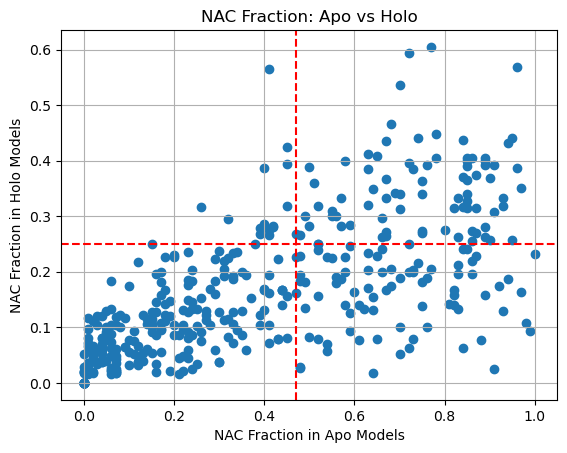

In [14]:
import matplotlib.pyplot as plt

nac_apo = [result_filtered[u]['nac_fraction_apo'] for u in uniprot_ids]
nac_holo = [result_filtered[u]['nac_fraction_holo'] for u in uniprot_ids]
plt.scatter(nac_apo, nac_holo)
plt.xlabel('NAC Fraction in Apo Models')
plt.ylabel('NAC Fraction in Holo Models')
plt.title('NAC Fraction: Apo vs Holo')
plt.axhline(y=thr_holo, color='r', linestyle='--', label=f'Threshold: {thr_holo:.2%}')
plt.axvline(x=thr_apo, color='r', linestyle='--', label=f'Threshold: {thr_apo:.2%}')

plt.grid(True)
plt.show()

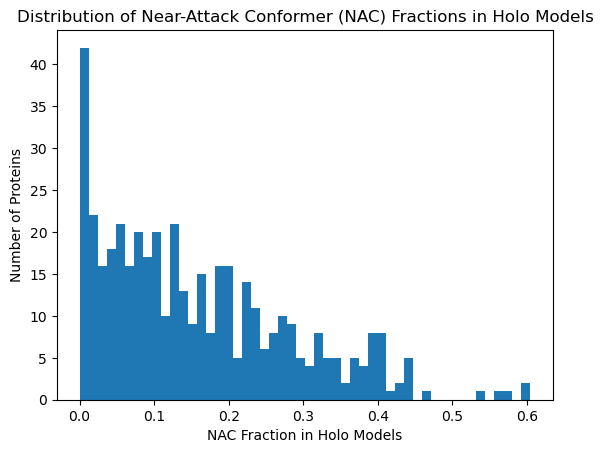

In [15]:
import matplotlib.pyplot as plt

plt.hist(nac_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

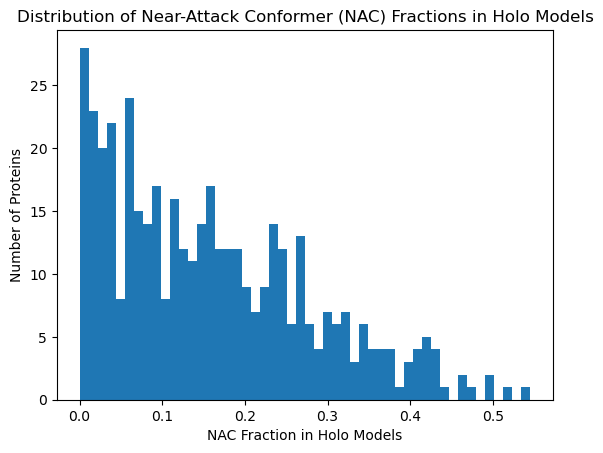

In [ ]:
import matplotlib.pyplot as plt

plt.hist(nac_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

Split PLACER outputs into the models to satisfy NAC geometry
------------------------------------------------------------------------------

In [17]:
cols = ['uniprot_id', 'nac_fraction_holo', 'nac_holo_idxs', 'n_confident_models',
        'prmsd_mean', 'prmsd_std', 'nac_fraction_apo', 'nac_apo_idxs']
all_results_df = pd.DataFrame([{k: r.get(k) for k in cols[1:]} | {'uniprot_id': uid}
                               for uid, r in all_results.items()])[cols]
candidate_df = all_results_df[all_results_df['uniprot_id'].isin(both)].reset_index(drop=True)

candidate_df['nac_holo_idxs'] = candidate_df['nac_holo_idxs'].apply(lambda idxs: ';'.join(str(idx + 1) for idx in idxs))
candidate_df['nac_apo_idxs'] = candidate_df['nac_apo_idxs'].apply(lambda idxs: ';'.join(str(idx + 1) for idx in idxs))
candidate_df.to_csv('results/carA_homologs_po_candidates_4.txt', index=False, sep = '\t')
# candidate_df = pd.read_csv('results/carA_homologs_po_candidates_4.txt', sep = '\t')
candidate_df

,uniprot_id,nac_fraction_holo,nac_holo_idxs,n_confident_models,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs
0,A0A0F5NA60,0.384615,1;3;5;6;11;12;15;18;19;25;28;29;31;35;36,39,2.559205,1.180066,0.73,1;2;3;4;5;6;7;9;11;12;13;15;16;18;21;22;23;24;...
1,A0A0H3MCY6,0.392857,1;2;5;9;10;11;14;18;19;20;21;25;26;27;29;35;38...,56,2.246222,1.320387,0.89,1;2;3;4;5;6;7;9;10;11;12;13;16;17;18;20;21;22;...
2,A0A0I9Z3I8,0.385965,4;5;6;7;9;11;13;14;19;20;22;24;27;36;38;39;40;...,57,2.195822,1.200208,0.96,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;17;18;19;2...
3,A0A0N9YG13,0.318182,3;4;5;10;15;19;20;24;26;27;28;30;36;43,44,2.551475,1.021390,0.52,1;2;3;4;6;8;9;12;13;15;18;20;22;23;24;26;32;35...
4,A0A0U0ZG49,0.363636,3;5;7;9;10;11;14;17;21;22;29;33,33,2.707640,1.071287,0.75,1;2;3;4;5;6;7;8;9;10;11;12;14;15;16;17;18;19;2...
...,...,...,...,...,...,...,...,...
66,A0AB73U9A3,0.340909,6;17;18;22;23;27;28;29;30;31;32;33;37;43;44,44,2.553055,1.137648,0.69,1;3;5;6;7;8;10;12;13;14;16;17;18;19;20;21;22;2...
67,E5XP76,0.404762,1;5;14;15;16;17;18;19;23;24;26;28;29;30;34;35;38,42,2.645886,1.181351,0.85,1;2;3;7;8;9;11;12;13;14;15;16;17;18;19;20;21;2...
68,H8IU56,0.264151,4;9;11;24;27;35;36;37;40;46;47;49;50;52,53,2.230051,1.051151,0.67,1;3;5;6;7;11;12;13;14;16;17;18;21;23;24;25;26;...
69,K0EY54,0.431818,2;4;5;7;9;14;17;21;22;24;26;28;29;30;31;32;33;...,44,2.450372,1.040333,0.94,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...


In [18]:
import os
from Bio.PDB import PDBIO
from tqdm import tqdm

src_dir = "outputs/placer/carA_holo_adi_amp_homologs_100_4"
dst_dir = "inputs/docking/carA_homologs_4"
os.makedirs(dst_dir, exist_ok=True)

io = PDBIO()
for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    uniprot_id = row['uniprot_id']
    base_name = f"carA_{uniprot_id}"
    src_path = os.path.join(src_dir, f"{base_name}.relax_model.pdb")

    out_dir = os.path.join(dst_dir, base_name)
    os.makedirs(out_dir, exist_ok=True)

    models = structure.load_models_from_pdb(src_path)
    for idx in row['nac_holo_idxs'].split(';'):
        idx = int(idx)
        io.set_structure(models[int(idx) - 1])   # 1-based -> 0-based
        io.save(os.path.join(out_dir, f"{base_name}.relax_model_{idx}.pdb"))

100%|██████████| 71/71 [01:12<00:00,  1.02s/it]


'2'